# 03 Clustering Analysis

This notebook conducts clustering analysis on the student dropout dataset, covering algorithm introduction, data loading, feature selection, clustering modeling, visualization, and multi-metric evaluation for K-means, Hierarchical Clustering, and Gaussian Mixture Model (GMM).

## 1. K-means algorithm

K-means is a commonly used distance-based clustering algorithm suitable for numerical features. Its goal is to divide data into K clusters such that the similarity of samples within the same cluster is maximized and the similarity between different clusters is minimized. It is applicable to large-sample datasets with standardized features.

In [1]:
import warnings
# macOS Accelerate BLAS emits spurious 'divide by zero / overflow in matmul'
# warnings during sklearn internals; fits converge correctly. Silence the noise.
warnings.filterwarnings('ignore', category=RuntimeWarning)

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Plotting style configuration
cluster_palette = ['#e41a1c', '#4daf4a', '#377eb8']
plt.rcParams.update({'figure.figsize': (10, 8), 'figure.dpi': 100})
plt.rcParams['savefig.dpi'] = 150
# Subplot margins to match tight_layout
plt.rcParams['figure.subplot.top'] = 0.95
plt.rcParams['figure.subplot.bottom'] = 0.05
plt.rcParams['figure.subplot.left'] = 0.05
plt.rcParams['figure.subplot.right'] = 0.95
# Seaborn style
sns.set_style('whitegrid')
POINT_SIZE = 10
POINT_ALPHA = 0.7
LEGEND_MARKERSCALE = 3
LEGEND_BBOX = dict(bbox_to_anchor=(1.05, 1), loc='upper left')

### 1.1. Read preprocessed data
Use the standardized and one-hot encoded data generated by 01_preprocessing.ipynb.

In [3]:
df = pd.read_csv('../data/data_preprocessed.csv')
df.shape, df.columns[:5]

((4424, 240),
 Index(['Application order', 'Daytime/evening attendance',
        'Previous qualification (grade)', 'Admission grade', 'Displaced'],
       dtype='object'))

### 1.2. Feature selection

Remove the target variable and encoded columns, and perform clustering using only the features.

In [4]:
# Use one-hot encoded dataframe (drop target columns) — expected feature dim ~238
drop_cols = [c for c in ['Target', 'Target_encoded'] if c in df.columns]
X = df.drop(columns=drop_cols)
X.shape

(4424, 238)

In [5]:
X_scaled = X.values
# PCA for 2D visualization (computed once and reused)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape
# t-SNE for 2D visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

### 1.3. K-means Clustering Modeling and Clustering Visualization Under Different K Values (PCA Dimensionality Reduction)

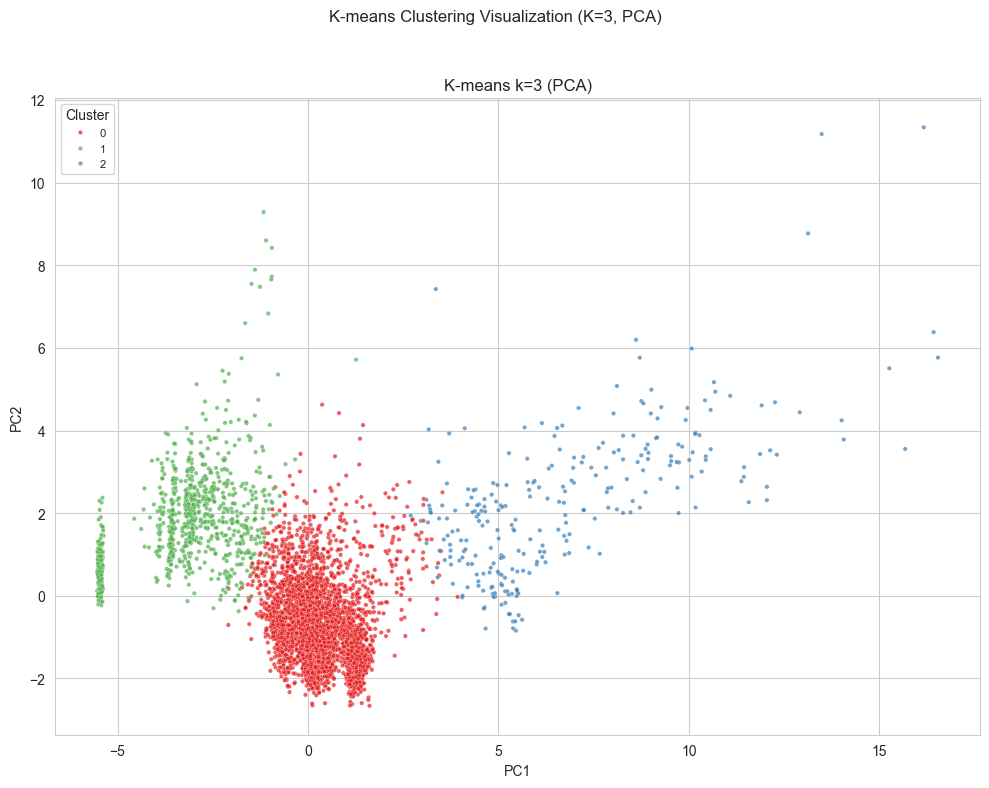

In [6]:
k_list = [3]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(k_list):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'K-means k={k} (PCA)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('K-means Clustering Visualization (K=3, PCA)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

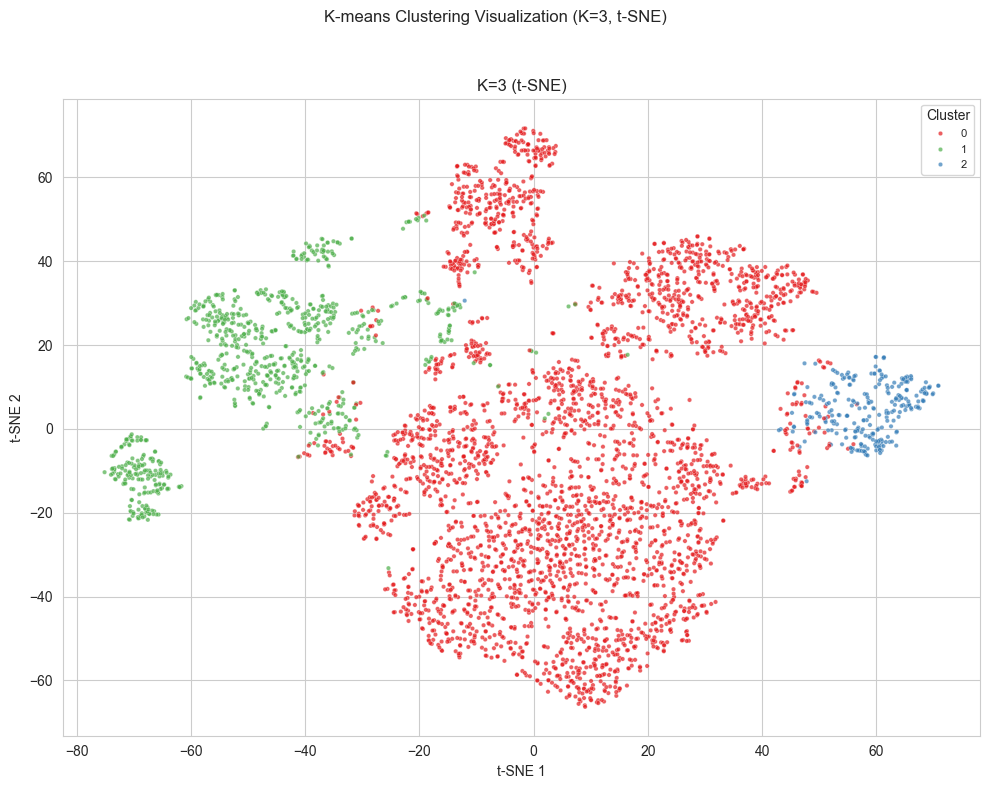

In [7]:
# K-means t-SNE visualization, directly reuse X_tsne
fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(k_list):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'K={k} (t-SNE)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('K-means Clustering Visualization (K=3, t-SNE)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 1.4. Clustering effect evaluation
The following compares various clustering evaluation metrics under different K values:
- Elbow Method: (As K increases, the SSE will keep decreasing, but when K is excessively large, the decline rate of SSE will become very small.) The "elbow" refers to the point where the SSE curve bends noticeably, and the K corresponding to the inflection point is regarded as the optimal number of clusters.
- Silhouette Coefficient: Measures intra-cluster compactness and inter-cluster separation, with a range of [-1, 1]; the closer to 1, the better.
- Calinski-Harabasz (CH): Ratio of inter-cluster variance to intra-cluster variance; the higher the value, the better.
- Davies-Bouldin (DB): Ratio of intra-cluster similarity to inter-cluster similarity; the lower the value, the better.
- ARI / Normalized Mutual Information (NMI): Compares clustering results with true labels; the closer to 1, the better.

In [8]:
def purity_score(y_true, y_pred):
    from scipy.stats import mode
    labels = np.unique(y_pred)
    total = 0
    for label in labels:
        mask = (y_pred == label)
        if np.sum(mask) == 0: continue
        if len(np.unique(y_true[mask])) == 0: continue
        
        m = mode(y_true[mask], keepdims=True)
        if hasattr(m, 'count'):
            total += m.count[0]
        else:
            total += m[1][0]
    return total / len(y_true)

K_range = [3]
inertia = []
silhouette = []
ch_score = []
db_score = []
ari_score = []
nmi_score = []
purity = []
true_labels = df['Target_encoded'] if 'Target_encoded' in df.columns else None

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette.append(silhouette_score(X_scaled, labels))
    ch_score.append(calinski_harabasz_score(X_scaled, labels))
    db_score.append(davies_bouldin_score(X_scaled, labels))
    if true_labels is not None:
        ari_score.append(adjusted_rand_score(true_labels, labels))
        nmi_score.append(normalized_mutual_info_score(true_labels, labels))
        purity.append(purity_score(true_labels, labels))
    else:
        ari_score.append(None)
        nmi_score.append(None)
        purity.append(None)

# Summarize K-means evaluation metrics as a table
results_kmeans = pd.DataFrame({
    'K': list(K_range),
    'Silhouette': silhouette,
    'CH': ch_score,
    'DB': db_score,
    'ARI': ari_score,
    'NMI': nmi_score,
    'Purity': purity,
})
display(results_kmeans.style.format({'Inertia': '{:.2f}', 'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('K-means Evaluation Metrics'))

,K,Silhouette,CH,DB,ARI,NMI,Purity
0,3,0.245,804.66,1.67,0.149,0.157,0.639


## 2. Hierarchical Clustering
Hierarchical Clustering constructs a clustering tree from data objects. Common hierarchical clustering methods include agglomerative (bottom-up merging) and divisive (top-down splitting), with agglomerative clustering being more widely used. Hierarchical clustering is suitable for data analysis scenarios with a small sample size where a hierarchical clustering structure is desired.

### 2.1 Hierarchical clustering dendrogram
Plot a dendrogram for hierarchical clustering to observe the hierarchical structure and clustering process of the samples.

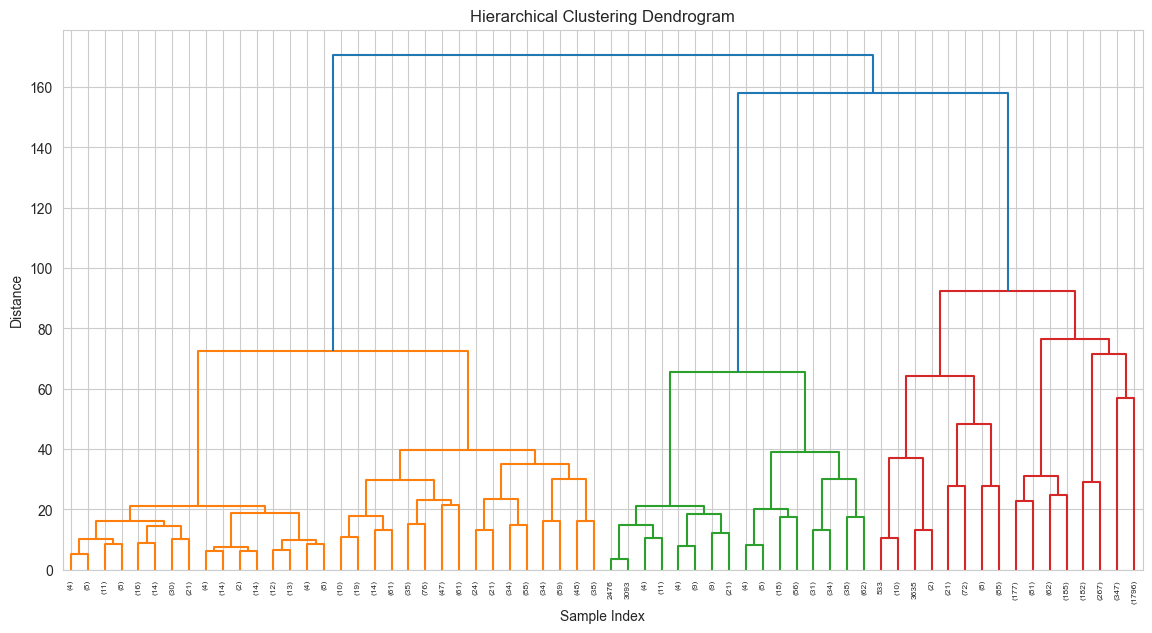

In [9]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Select the distance metric and linkage method for hierarchical clustering; try 'ward','average', 'complete', 'single'
# Among them, 'ward' is applicable to Euclidean distance, 'average' represents average distance, 
# 'complete' represents maximum distance, and 'single' represents minimum distance.
linkage_method = 'ward'

# Calculate the linkage matrix for hierarchical clustering
Z = linkage(X_scaled, method=linkage_method)

# Draw a dendrogram, the x-axis ticks will be displayed automatically.
plt.figure(figsize=(12, 6))
dendro = dendrogram(Z, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

### 2.2 Hierarchical Clustering Visualization (PCA Dimensionality Reduction)
After reducing the data to two dimensions, display the clustering distribution under different numbers of clusters.

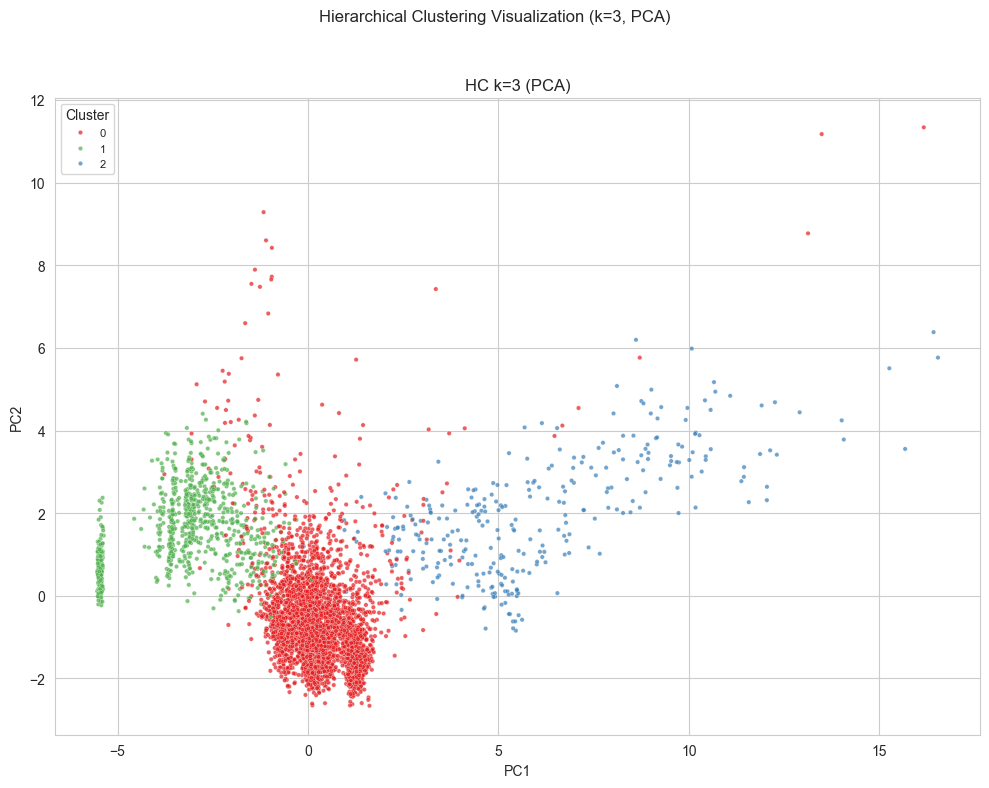

In [10]:
hc_k_list = [3]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(hc_k_list):
    hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    hc_labels = hc.fit_predict(X_scaled)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hc_labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'HC k={k} (PCA)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('Hierarchical Clustering Visualization (k=3, PCA)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

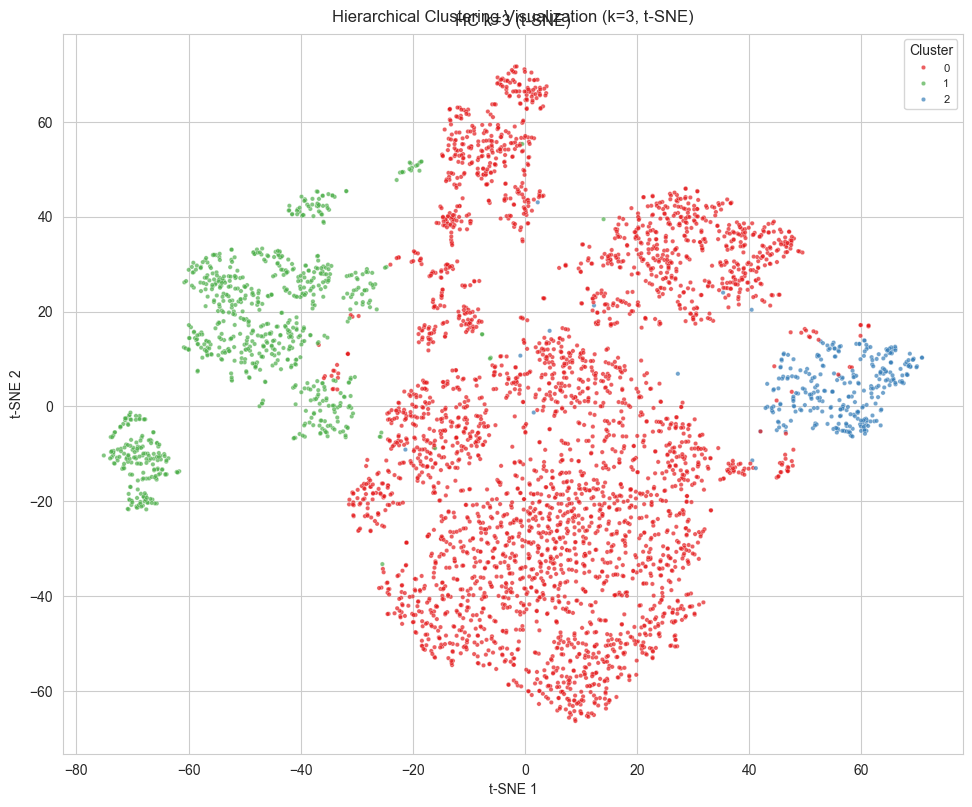

In [11]:
# Hierarchical Clustering t-SNE visualization
hc_k_list = [3]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(hc_k_list):
    hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    hc_labels = hc.fit_predict(X_scaled)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=hc_labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'HC k={k} (t-SNE)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('Hierarchical Clustering Visualization (k=3, t-SNE)')
plt.show()

### 2.3 Clustering Evaluation of Hierarchical Clustering with Different Numbers of Clusters
Conduct multi-index evaluation on hierarchical clustering results under different cluster numbers（Silhouette、Calinski-Harabasz、Davies-Bouldin、ARI、NMI）。

In [12]:
hc_silhouette = []
hc_ch_score = []
hc_db_score = []
hc_ari_score = []
hc_nmi_score = []
hc_purity = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    hc_labels = hc.fit_predict(X_scaled)
    hc_silhouette.append(silhouette_score(X_scaled, hc_labels))
    hc_ch_score.append(calinski_harabasz_score(X_scaled, hc_labels))
    hc_db_score.append(davies_bouldin_score(X_scaled, hc_labels))
    if true_labels is not None:
        hc_ari_score.append(adjusted_rand_score(true_labels, hc_labels))
        hc_nmi_score.append(normalized_mutual_info_score(true_labels, hc_labels))
        hc_purity.append(purity_score(true_labels, hc_labels))
    else:
        hc_ari_score.append(None)
        hc_nmi_score.append(None)
        hc_purity.append(None)

# Summarize Hierarchical clustering evaluation metrics as a table
results_hc = pd.DataFrame({
    'K': list(K_range),
    'Silhouette': hc_silhouette,
    'CH': hc_ch_score,
    'DB': hc_db_score,
    'ARI': hc_ari_score,
    'NMI': hc_nmi_score,
    'Purity': hc_purity,
})
display(results_hc.style.format({'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('Hierarchical Clustering Evaluation Metrics'))

,K,Silhouette,CH,DB,ARI,NMI,Purity
0,3,0.218,729.21,1.71,0.142,0.149,0.634


## 3. Gaussian Mixture Model (GMM) 

Gaussian Mixture Model (GMM) is a clustering method based on probabilistic models, which assumes that data is formed by the mixture of multiple Gaussian distributions. Parameters are estimated through the Expectation-Maximization (EM) algorithm, and the probability of each sample belonging to each cluster is output.

### 3.1 Usage and Visualization of the GMM Algorithm

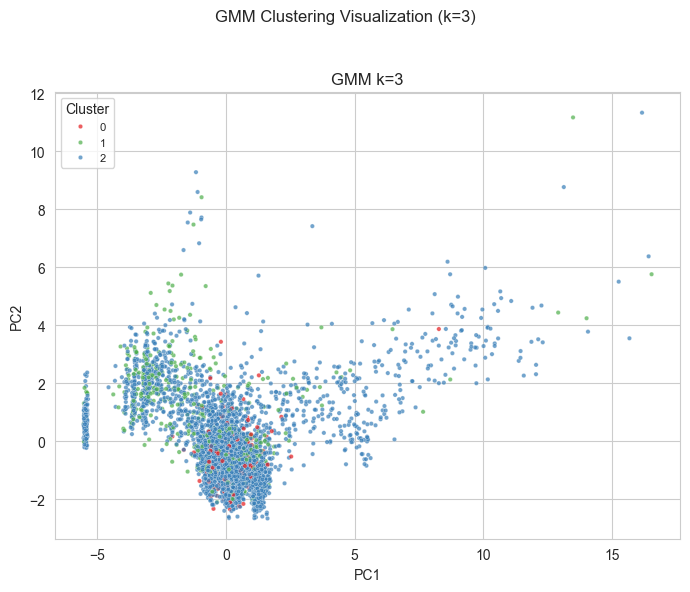

In [13]:
from sklearn.mixture import GaussianMixture

# Select cluster number K=3 only
k_list = [3]

fig, ax = plt.subplots(figsize=(7, 6))
for idx, k in enumerate(k_list):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5)
    gmm_labels = gmm.fit_predict(X_scaled)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=gmm_labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'GMM k={k}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('GMM Clustering Visualization (k=3)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

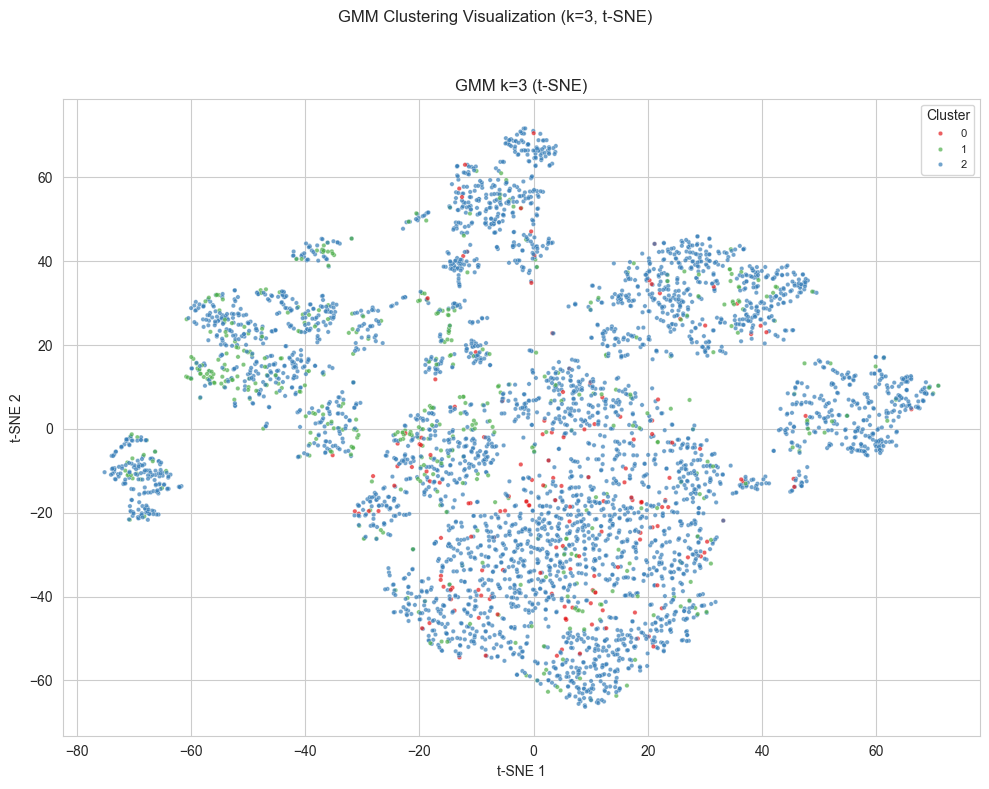

In [14]:
# GMM t-SNE visualization, directly reuse X_tsne
k_list = [3]

fig, ax = plt.subplots(figsize=(10, 8))
for idx, k in enumerate(k_list):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5)
    gmm_labels = gmm.fit_predict(X_scaled)
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=gmm_labels, palette=cluster_palette, alpha=POINT_ALPHA, s=POINT_SIZE, ax=ax, legend='full')
    ax.set_title(f'GMM k={k} (t-SNE)')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Cluster', fontsize=8)
plt.suptitle('GMM Clustering Visualization (k=3, t-SNE)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 3.2 Multi-index Evaluation of GMM Clustering Performance

For the GMM clustering results under different K values, calculate metrics such as silhouette coefficient, Calinski-Harabasz, Davies-Bouldin, ARI, and NMI.

In [15]:
gmm_silhouette = []
gmm_ch_score = []
gmm_db_score = []
gmm_ari_score = []
gmm_nmi_score = []
gmm_purity = []

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_silhouette.append(silhouette_score(X_scaled, gmm_labels))
    gmm_ch_score.append(calinski_harabasz_score(X_scaled, gmm_labels))
    gmm_db_score.append(davies_bouldin_score(X_scaled, gmm_labels))
    if true_labels is not None:
        gmm_ari_score.append(adjusted_rand_score(true_labels, gmm_labels))
        gmm_nmi_score.append(normalized_mutual_info_score(true_labels, gmm_labels))
        gmm_purity.append(purity_score(true_labels, gmm_labels))
    else:
        gmm_ari_score.append(None)
        gmm_nmi_score.append(None)
        gmm_purity.append(None)

# Summarize GMM evaluation metrics as a table
results_gmm = pd.DataFrame({
    'K': list(K_range),
    'Silhouette': gmm_silhouette,
    'CH': gmm_ch_score,
    'DB': gmm_db_score,
    'ARI': gmm_ari_score,
    'NMI': gmm_nmi_score,
    'Purity': gmm_purity,
})
display(results_gmm.style.format({'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('GMM Evaluation Metrics'))

,K,Silhouette,CH,DB,ARI,NMI,Purity
0,3,-0.058,21.32,7.29,0.020,0.022,0.524


## 4. Comparison of Three Clustering Algorithms and Performance Analysis in This Project

This section condenses the K=3 results from the tables above into a short comparison. The goal is to highlight the overall ranking without repeating every metric in full.

In [16]:
# Build the comparison table directly from the previously generated result tables
comparison_df = pd.concat([
    results_kmeans.loc[[0], ['K', 'Silhouette', 'CH', 'DB', 'ARI', 'NMI', 'Purity']].assign(Algorithm='K-means'),
    results_hc.loc[[0], ['K', 'Silhouette', 'CH', 'DB', 'ARI', 'NMI', 'Purity']].assign(Algorithm='Hierarchical'),
    results_gmm.loc[[0], ['K', 'Silhouette', 'CH', 'DB', 'ARI', 'NMI', 'Purity']].assign(Algorithm='GMM'),
] , ignore_index=True)

comparison_df = comparison_df[['Algorithm', 'K', 'Silhouette', 'CH', 'DB', 'ARI', 'NMI', 'Purity']]

display(comparison_df.style.format({'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('Condensed Comparison at K=3'))

,Algorithm,K,Silhouette,CH,DB,ARI,NMI,Purity
0,K-means,3,0.245,804.66,1.67,0.149,0.157,0.639
1,Hierarchical,3,0.218,729.21,1.71,0.142,0.149,0.634
2,GMM,3,-0.058,21.32,7.29,0.020,0.022,0.524


At $K=3$, the three algorithms show a clearer ranking on this dataset: **K-means** performs best overall, **Hierarchical** is a close second, and **GMM** is clearly the weakest. K-means achieves the strongest internal metrics among the three, while its external alignment with the true labels is also slightly better than Hierarchical clustering. GMM, by contrast, has negative silhouette and much poorer agreement with the labels, so it does not fit this feature space well.

## 5. Detailed analysis and discussion

### 5.1 Indicator Interpretation
The ranking in Section 4 is not accidental. It reflects the geometry of the current feature space: after one-hot encoding, the data becomes sparse, high-dimensional, and mostly composed of binary indicator columns. That kind of representation is usually easier for distance-based and partition-based methods than for density-based Gaussian mixtures.


- **K-means** fits this setting best. It works directly with Euclidean distance and tries to form compact, centroid-driven groups. In a sparse one-hot space, this often behaves well because samples from the same hidden category tend to share many active features, so the cluster centers are meaningful. That matches the results we see: the best Silhouette, CH, DB, ARI, NMI, and Purity all belong to K-means.

- **Hierarchical** clustering is slightly weaker but still reasonable. It can capture nested grouping structure and does not require the objective to be optimized globally at once. On this dataset, that is enough to recover much of the broad grouping pattern, but it is still constrained by the linkage choice and by the fact that the data do not form perfectly separated blocks. As a result, its metrics stay close to K-means but do not surpass it.

- **GMM** performs poorly because its assumptions do not match the data geometry. GMM expects each cluster to look roughly Gaussian or at least elliptical in feature space, with covariance that can be estimated reliably. Here, however, the features are one-hot indicators rather than continuous Gaussian variables, so the true clusters are sparse, axis-aligned, and irregular rather than ellipsoidal. In that situation, EM tends to fit weak or unstable covariance structures, which explains the negative Silhouette, the very small CH score, the large DB score, and the much lower external agreement scores.

- In short, the current dataset is not naturally organized as a mixture of Gaussian blobs. It is better viewed as a sparse categorical feature space with some dominant partitions, which is exactly the kind of structure K-means and, to a lesser extent, Hierarchical clustering can exploit.


### 5.2 Applicability of different algorithms

- **K-means**: Best choice here because the data are sparse and partition-like, so centroid-based grouping is stable and effective.

- **Hierarchical**: A useful secondary method for confirming the broad partition structure, but not the strongest performer.

- **GMM**: Not recommended for this preprocessing setup, because the Gaussian assumption is too strong for the one-hot feature space.


### 5.3 Conclusion

When $K=3$ :

- **K-means** is the primary recommendation because it achieves the best balance of compactness, separation, and agreement with the true labels.

- **Hierarchical** is a reasonable backup method, but it remains slightly below K-means.

- **GMM** is the weakest method in this setting, mainly because the data are sparse and non-Gaussian rather than ellipsoidal and density-driven.